# Phase 1: Environment & Data Validation — Euro 2024

**Project:** A Perception-Aware Framework for Evaluating Counterfactual Passing Options in Professional Football

**Author:** Raeesa Lorgat (2686242)

**Purpose of this notebook:** before building the full three-layer pipeline (vision-cone filter, bias analysis, LSTM memory model) across the whole Euro 2024 competition, this notebook validates the pipeline end-to-end on a **single match**. The goal is to confirm the data actually contains what the methodology needs, and that the core Layer 1 geometry (the 120° feasibility cone) works correctly, before scaling up.

**Why this matters:** StatsBomb 360 data does not include a body-orientation field (confirmed below). This notebook documents that gap and the workaround adopted: approximating a player's facing direction from their movement vector into the pass (previous touch → pass location), rather than a true torso-orientation reading.

**Dataset used:** UEFA Euro 2024 (`competition_id=55`, `season_id=282`), single match: Spain vs England, Final (`match_id=3943043`).

Query StatsBomb's open-data competition list and filter for Euro 2024, to get the exact `competition_id` and `season_id` needed for every subsequent call.

In [2]:
from statsbombpy import sb
comps = sb.competitions()
comps[comps['competition_name'].str.contains('Euro', case=False)]

c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
73,55,282,Europe,UEFA Euro,male,False,True,2024,2026-05-01T19:54:25.846072,2026-05-01T19:58:06.077979,2026-05-01T19:58:06.077979,2026-05-01T19:54:25.846072
74,55,43,Europe,UEFA Euro,male,False,True,2020,2026-05-10T12:59:26.302088,2026-05-10T13:00:25.564993,2026-05-10T13:00:25.564993,2026-05-10T12:59:26.302088
75,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2026-04-11T12:48:10.012987,2021-06-13T16:17:31.694,None,2026-04-11T12:48:10.012987
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896


List all matches in the competition so a single match can be selected for pipeline validation.

In [3]:
COMPETITION_ID = 55
SEASON_ID = 282

matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
matches[['match_id', 'match_date', 'home_team', 'away_team', 'competition_stage']]

c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,home_team,away_team,competition_stage
0,3930166,2024-06-18,Portugal,Czech Republic,Group Stage
1,3930159,2024-06-15,Hungary,Switzerland,Group Stage
2,3930163,2024-06-16,Serbia,England,Group Stage
3,3930181,2024-06-25,England,Slovenia,Group Stage
4,3930178,2024-06-24,Croatia,Italy,Group Stage
5,3930160,2024-06-15,Spain,Croatia,Group Stage
6,3930170,2024-06-20,Slovenia,Serbia,Group Stage
7,3938643,2024-06-25,France,Poland,Group Stage
8,3938641,2024-06-21,Poland,Austria,Group Stage
9,3938642,2024-06-22,Georgia,Czech Republic,Group Stage


Selected the final (Spain vs England) as the validation match. `events` holds every on-ball action; `frames` holds the 360 freeze-frame data (player locations visible at each event).

In [5]:
match_id = "3943043" # the final

events = sb.events(match_id=match_id)
frames = sb.frames(match_id=match_id, fmt='dataframe')

c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Inspect the 360 frame schema

In [6]:
print("EVENTS shape:", events.shape)
print("FRAMES shape:", frames.shape)
print("\nFRAMES columns:")
print(frames.columns.tolist())

EVENTS shape: (3304, 92)
FRAMES shape: (47480, 7)

FRAMES columns:
['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']


**Finding:** `frames` only contains `['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']` , no body-orientation or player-identity field. 

Confirm orientation isn't hiding in the event data either

In [7]:
print("EVENTS columns:")
print(events.columns.tolist())

EVENTS columns:
['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'block_save_block', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_no_touch', 'pass_outcom

Checked all 92 event-level columns for anything resembling body orientation (as opposed to pass angle, which is a different thing). Confirmed: no such field exists anywhere in StatsBomb open data. Arbues-Sanguesa et al. [2020], who the 120° cone is drawn from, derived orientation from Bundesliga tracking/video data (not StatsBomb).

**Resolution:** use a movement-direction proxy instead, the vector from a player's previous touch to their current pass location approximates the direction they were facing/moving into the pass. This is a methodological adaptation to document in the write-up, not a change to the three-layer framework itself.

Build the movement-direction orientation proxy.

For each player, find their previous on-ball touch within the match (ordered by possession, then event index). The vector from that previous location to the current pass location approximates their facing direction.

In [8]:
import numpy as np

# Keep only on-ball events with a location, ordered as they happened
events_sorted = events.sort_values(['possession', 'index']).reset_index(drop=True)

# For each player, get their previous event's location
events_sorted['prev_location'] = events_sorted.groupby('player_id')['location'].shift(1)
events_sorted['prev_player_id'] = events_sorted.groupby('player_id')['player_id'].shift(1)

Convert the raw (dx, dy) movement into a unit vector, so it can be directly compared against the direction to any teammate using the angle formula from the proposal (Equation 4.1). Passes with no valid previous touch (e.g. a player's first touch of a possession) are marked `None` and will be excluded.

In [9]:
def compute_orientation_vector(row):
    if row['prev_location'] is None or not isinstance(row['prev_location'], list):
        return None
    if row['location'] is None or not isinstance(row['location'], list):
        return None
    dx = row['location'][0] - row['prev_location'][0]
    dy = row['location'][1] - row['prev_location'][1]
    norm = np.sqrt(dx**2 + dy**2)
    if norm == 0:
        return None
    return (dx / norm, dy / norm)

passes = events_sorted[events_sorted['type'] == 'Pass'].copy()
passes['orientation_vector'] = passes.apply(compute_orientation_vector, axis=1)

print(passes['orientation_vector'].notna().sum(), "of", len(passes), "passes have a valid orientation proxy")

804 of 915 passes have a valid orientation proxy


Excluding the passes with no valid previous touch affects ~12% of passes in the validation match and will be documented as a limitation.

Before trusting the geometry, plot one pass: previous touch (grey), pass location (blue), and the resulting orientation vector (red arrow). The arrow should visually continue the direction of travel from grey to blue. 

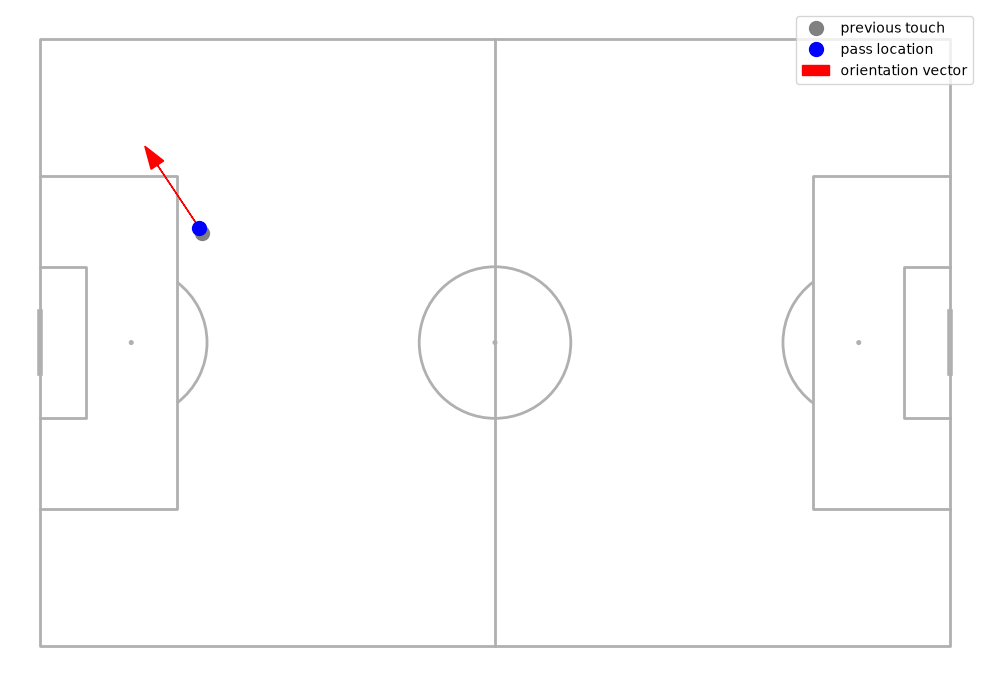

In [10]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# grab one valid example
example = passes[passes['orientation_vector'].notna()].iloc[10]

prev_loc = example['prev_location']
curr_loc = example['location']
vec = example['orientation_vector']

pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

# previous location (grey) -> current location (blue)
ax.plot(prev_loc[0], prev_loc[1], 'o', color='grey', markersize=10, label='previous touch')
ax.plot(curr_loc[0], curr_loc[1], 'o', color='blue', markersize=10, label='pass location')

# draw the orientation vector as an arrow from current location
arrow_scale = 10
ax.arrow(curr_loc[0], curr_loc[1], vec[0]*arrow_scale, vec[1]*arrow_scale,
          head_width=2, color='red', label='orientation vector')

ax.legend()
plt.savefig('../figures/orientation_vector_example.png', dpi=150, bbox_inches='tight')
plt.show()

Implement the 120° feasibility cone (Equation 4.1)

For a given pass, pull all teammates visible in the 360 freeze frame, then compute the angle between the passer's orientation vector and the vector to each teammate. A teammate is classified `visible` if that angle is ≤ 60° (i.e. within the ±60° half-cone, spanning the full 120° field).

In [11]:
def get_teammates_in_frame(match_id, event_id, frames_df, events_df):
    """Get all teammate locations visible in the 360 frame for a given event."""
    frame_rows = frames_df[frames_df['id'] == event_id]
    teammates = frame_rows[(frame_rows['teammate'] == True) & (frame_rows['actor'] == False)]
    return teammates

def angle_to_teammate(passer_loc, passer_orientation, teammate_loc):
    """Compute angle (degrees) between passer's orientation vector and vector to teammate."""
    v_passer = np.array(passer_orientation)
    v_teammate = np.array([teammate_loc[0] - passer_loc[0], teammate_loc[1] - passer_loc[1]])
    
    norm_teammate = np.linalg.norm(v_teammate)
    if norm_teammate == 0:
        return None
    
    v_teammate_unit = v_teammate / norm_teammate
    cos_angle = np.clip(np.dot(v_passer, v_teammate_unit), -1.0, 1.0)
    angle_deg = np.degrees(np.arccos(cos_angle))
    return angle_deg

Test the cone on the same example pass

Applied the angle/visibility function to all 8 teammates present in this pass's 360 frame. Result: angles ranged 36°–171°, with only the one teammate inside the 60° threshold (36°) classified as visible.

In [12]:
example_id = example['id']
example_match = example['match_id']

teammates_in_view = get_teammates_in_frame(example_match, example_id, frames, events_sorted)
print(f"{len(teammates_in_view)} teammates in 360 frame for this pass")

teammates_in_view = teammates_in_view.copy()
teammates_in_view['angle_to_passer_orientation'] = teammates_in_view['location'].apply(
    lambda loc: angle_to_teammate(curr_loc, vec, loc)
)
teammates_in_view['visible'] = teammates_in_view['angle_to_passer_orientation'] <= 60

print(teammates_in_view[['location', 'angle_to_passer_orientation', 'visible']])

8 teammates in 360 frame for this pass
                                     location  angle_to_passer_orientation  \
964  [14.269641836890372, 41.545479543793334]                   124.294701   
965  [15.724293881701854, 28.611986436361466]                    91.440149   
967    [19.74153904490182, 49.91251814205276]                   143.429625   
971  [21.136099666255163, 21.555430141641107]                    36.020303   
973    [23.81814644414058, 43.95543692695858]                   154.722539   
975  [31.138073215642333, 22.833846975809948]                   112.170865   
976  [36.225336278148134, 57.500616666681495]                   171.343731   
977    [41.05062588495932, 39.22565175863359]                   159.234890   

     visible  
964    False  
965    False  
967    False  
971     True  
973    False  
975    False  
976    False  
977    False  


Plot the passer, orientation arrow, the ±60° cone boundaries (orange dashed lines), and all teammates (green = visible, grey = not).

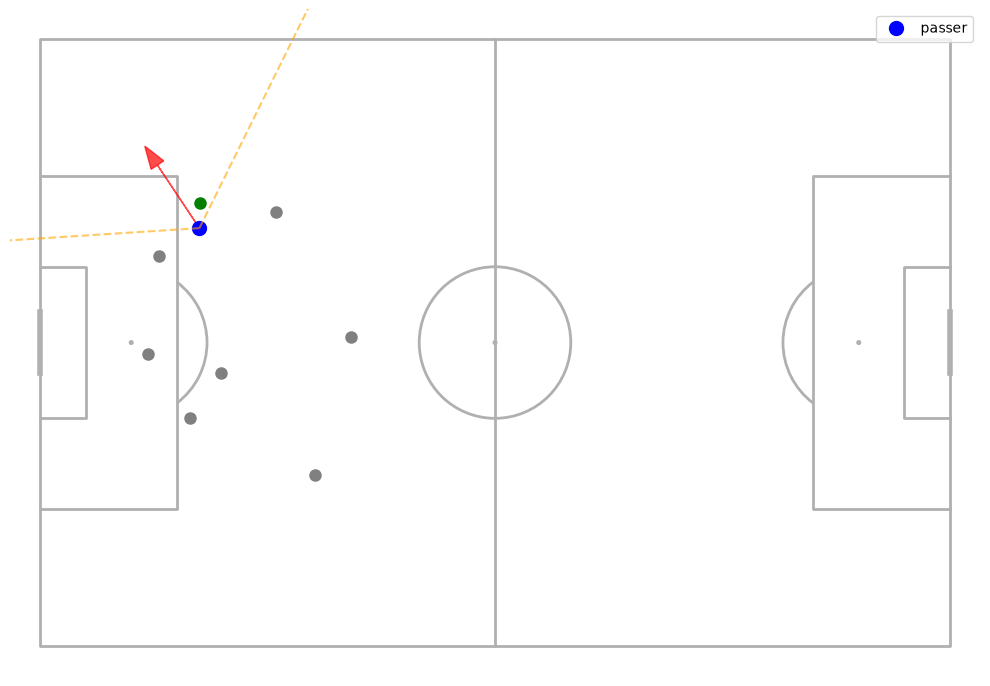

In [13]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

# passer and orientation arrow
ax.plot(curr_loc[0], curr_loc[1], 'o', color='blue', markersize=10, label='passer')
ax.arrow(curr_loc[0], curr_loc[1], vec[0]*10, vec[1]*10,
          head_width=2, color='red', alpha=0.7)

# draw the 120° cone as two boundary lines at ±60° from orientation
angle_center = np.degrees(np.arctan2(vec[1], vec[0]))
for offset in [-60, 60]:
    boundary_angle = np.radians(angle_center + offset)
    bx = curr_loc[0] + 40 * np.cos(boundary_angle)
    by = curr_loc[1] + 40 * np.sin(boundary_angle)
    ax.plot([curr_loc[0], bx], [curr_loc[1], by], '--', color='orange', alpha=0.6)

# teammates: green if visible, grey if not
for _, row in teammates_in_view.iterrows():
    color = 'green' if row['visible'] else 'grey'
    ax.plot(row['location'][0], row['location'][1], 'o', color=color, markersize=8)

ax.legend()
plt.savefig('../figures/vision_cone_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

Confirmed: only the teammate falling inside the wedge is marked visible. Layer 1's core geometry is validated on a single pass.

**Next step:** generalize this into a function that runs over every pass in the match (not just this one example), producing a full visible/invisible teammate table which is the actual output needed for the RQ1 comparison.

Scale the vision-cone filter to every pass in the match

So far the cone logic (Steps 9–11) has only been tested on one example pass. Now generalize it: for every pass in the match that has a valid orientation vector, pull all teammates from its 360 freeze frame, classify each as visible/invisible using the 60° threshold, and store the results.

This produces the actual per-pass output the RQ1 comparison needs: for each pass, how many teammates were visible vs. invisible, and which ones.

In [14]:
def classify_pass_visibility(passer_loc, passer_orientation, match_id, event_id, frames_df):
    """
    For one pass, return all teammates in its 360 frame with angle-to-orientation
    and visibility classification.
    """
    teammates = get_teammates_in_frame(match_id, event_id, frames_df, None)
    
    if teammates.empty:
        return None
    
    teammates = teammates.copy()
    teammates['angle_to_orientation'] = teammates['location'].apply(
        lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
    )
    teammates = teammates.dropna(subset=['angle_to_orientation'])
    teammates['visible'] = teammates['angle_to_orientation'] <= 60
    
    return teammates

Apply the classifier across all valid passes

Loop over every pass with a valid orientation vector, run the classifier, and record summary counts (teammates in frame, number visible, number invisible) per pass. Passes with no 360 frame data available (e.g. off-camera events) are skipped and counted separately.

In [15]:
import pandas as pd

results = []

valid_passes = passes[passes['orientation_vector'].notna()]

for _, row in valid_passes.iterrows():
    classified = classify_pass_visibility(
        passer_loc=row['location'],
        passer_orientation=row['orientation_vector'],
        match_id=row['match_id'],
        event_id=row['id'],
        frames_df=frames
    )
    
    if classified is None or classified.empty:
        results.append({
            'pass_id': row['id'],
            'has_360_frame': False,
            'n_teammates': 0,
            'n_visible': 0,
            'n_invisible': 0
        })
    else:
        results.append({
            'pass_id': row['id'],
            'has_360_frame': True,
            'n_teammates': len(classified),
            'n_visible': int(classified['visible'].sum()),
            'n_invisible': int((~classified['visible']).sum())
        })

pass_visibility = pd.DataFrame(results)
print(f"{len(pass_visibility)} passes processed")
print(f"{pass_visibility['has_360_frame'].sum()} had usable 360 frame data")

804 passes processed
667 had usable 360 frame data


Document the data coverage funnel

Before analyzing results, it's important to know exactly how much of the original data survives each filtering stage as this becomes a limitation/methodology note in the dissertation.

- Total passes in match: starting point
- Passes with a valid orientation proxy (Step 6): requires a prior touch by the same player
- Passes with usable 360 frame data (Step 13): requires StatsBomb to have captured a freeze frame for that event

Both exclusions are legitimate and expected but the final "clean" sample is smaller than the raw pass count, and this should be reported transparently.

In [16]:
total_passes = len(passes)
with_orientation = len(valid_passes)
with_360 = pass_visibility['has_360_frame'].sum()

print(f"Total passes in match:              {total_passes}")
print(f"With valid orientation proxy:       {with_orientation} ({with_orientation/total_passes:.1%})")
print(f"With usable 360 frame data:         {with_360} ({with_360/total_passes:.1%})")
print(f"Final clean sample for Layer 1:     {with_360} ({with_360/total_passes:.1%} of total)")

Total passes in match:              915
With valid orientation proxy:       804 (87.9%)
With usable 360 frame data:         667 (72.9%)
Final clean sample for Layer 1:     667 (72.9% of total)


Summary statistics on visibility

For the clean sample, look at the distribution of how many teammates were visible vs. invisible per pass. This is the first substantive empirical result of the project: it shows, on average, how much of the pitch a player realistically "sees" at the moment of a pass, compared to the total number of teammates technically on the pitch.

In [17]:
clean = pass_visibility[pass_visibility['has_360_frame']]

print("Teammates in 360 frame per pass:")
print(clean['n_teammates'].describe())

print("\nVisible teammates per pass:")
print(clean['n_visible'].describe())

print("\nInvisible teammates per pass:")
print(clean['n_invisible'].describe())

print(f"\nOn average, {clean['n_visible'].mean():.2f} of {clean['n_teammates'].mean():.2f} "
      f"teammates in frame were within the 120° cone "
      f"({clean['n_visible'].mean()/clean['n_teammates'].mean():.1%})")

Teammates in 360 frame per pass:
count    667.000000
mean       7.170915
std        1.624935
min        1.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       10.000000
Name: n_teammates, dtype: float64

Visible teammates per pass:
count    667.000000
mean       2.371814
std        1.968136
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       10.000000
Name: n_visible, dtype: float64

Invisible teammates per pass:
count    667.000000
mean       4.799100
std        2.115678
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       10.000000
Name: n_invisible, dtype: float64

On average, 2.37 of 7.17 teammates in frame were within the 120° cone (33.1%)


Sanity-check an anomaly

`n_visible` shows a max of 10 while `n_teammates` has a mean of ~7 — worth confirming `n_visible` never exceeds `n_teammates` for any single pass, since that would indicate a bug in the classification logic rather than a real result.

In [18]:
bad_rows = clean[clean['n_visible'] > clean['n_teammates']]
print(f"Passes where n_visible > n_teammates: {len(bad_rows)}")
print(bad_rows[['pass_id', 'n_teammates', 'n_visible', 'n_invisible']])

Passes where n_visible > n_teammates: 0
Empty DataFrame
Columns: [pass_id, n_teammates, n_visible, n_invisible]
Index: []


Save Layer 1 output for this match

Before moving on to VAEP and the RQ1 comparison, save the per-pass visibility classifications to disk. This becomes the input to Layer 2 (bias analysis) and the basis for the RQ1 omniscient-vs-filtered comparison.

In [19]:
import os
os.makedirs('../data', exist_ok=True)

clean.to_parquet('../data/euro2024_final_pass_visibility.parquet')
valid_passes.to_parquet('../data/euro2024_final_passes_with_orientation.parquet')

print("Saved:")
print("  ../data/euro2024_final_pass_visibility.parquet")
print("  ../data/euro2024_final_passes_with_orientation.parquet")

Saved:
  ../data/euro2024_final_pass_visibility.parquet
  ../data/euro2024_final_passes_with_orientation.parquet


Move logic into `src/` for reuse

The functions built so far (`compute_orientation_vector`, `angle_to_teammate`, `get_teammates_in_frame`, `classify_pass_visibility`) are stable and will be reused across every match once this pipeline scales to the full competition. Rather than keep them only in this notebook, they belong in `src/vision_cone.py` so they can be imported cleanly into future notebooks and scripts (Layer 2, Layer 3, full-competition runs).

In [20]:
import sys
sys.path.append('..')
from src.vision_cone import add_orientation_vectors, build_pass_visibility_table

# re-run the whole pipeline using the src module, should match your existing results
events_check = add_orientation_vectors(events)
passes_check = events_check[events_check['type'] == 'Pass'].copy()
visibility_check = build_pass_visibility_table(passes_check, frames)

print(visibility_check['has_360_frame'].sum(), "passes with usable 360 data (should be 667)")

667 passes with usable 360 data (should be 667)


Bring in socceraction for action valuation (VAEP)

So far, Layer 1 tells us which teammates were visible at the moment of each pass. To answer RQ1, we now need to value passes - is the chosen pass actually better or worse than the visible alternatives?

socceraction does not ship a pretrained VAEP model. It provides the framework (SPADL conversion, feature engineering, the VAEP formula), but the scoring/conceding probability models must be trained on data we provide. A single match (~3,300 actions, a handful of goals) is far too small to train a meaningful model, so this validates the conversion pipeline only. Actual VAEP model training will happen once Layer 1 is scaled to the full Euro 2024 competition (51 matches), giving a large enough, goal-rich dataset to fit on.

This step uses socceraction's own `StatsBombLoader` (separate from `statsbombpy`, used earlier for Layer 1) because its output format is what `convert_to_actions` expects.

In [21]:
from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl

SBL = StatsBombLoader(getter="remote")

games = SBL.games(competition_id=COMPETITION_ID, season_id=SEASON_ID)
game_row = games[games['game_id'] == int(match_id)]
print(game_row[['game_id', 'home_team_id', 'away_team_id', 'game_date']])

    game_id  home_team_id  away_team_id           game_date
22  3943043           772           768 2024-07-14 19:00:00


Convert the match to SPADL format

SPADL (Soccer Player Action Description Language) is socceraction's unified action representation, a cleaned-up, standardized version of the raw event stream that VAEP's feature engineering expects. This step loads the raw events for this match via socceraction's own loader (not statsbombpy) and converts them.

In [22]:
home_team_id = int(game_row['home_team_id'].iloc[0])

sb_events = SBL.events(game_id=int(match_id))
actions = spadl.statsbomb.convert_to_actions(sb_events, home_team_id=home_team_id)

print(f"{len(actions)} actions converted")
actions.head()

c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\data\statsbomb\loader.py:337: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eventsdf["under_pressure"] = eventsdf["under_pressure"].fillna(False).astype(bool)
c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\data\statsbomb\loader.py:338: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eventsdf["counterpress"] = eventsdf["counterpress"].fillna(False).astype(bool)


1877 actions converted


c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\spadl\statsbomb.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  events["extra"].fillna({}, inplace=True)


,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id
0,3943043,277afcf7-04cb-4768-b41c-2b421d657d1d,1,0.340,768,99174.0,52.54375,33.9575,82.81875,32.9375,0,1,5,0
1,3943043,4a701432-ef81-4b8d-aad8-0eda8205610c,1,2.870,768,3468.0,82.81875,32.9375,79.93125,26.8175,21,1,0,1
2,3943043,76458596-db8b-457e-952a-5f0b1bdfdb71,1,4.742,768,3468.0,79.93125,26.8175,0.04375,57.5025,0,0,4,2
3,3943043,9e7d4081-2230-4b76-af41-3b00d2cd6ab8,1,34.440,772,11748.0,5.99375,34.3825,7.91875,19.4225,22,1,4,3
4,3943043,fa1cb9c6-cfc7-4379-9ed1-92ed11278435,1,35.658,772,22128.0,7.91875,19.4225,7.74375,19.4225,21,1,0,4


The raw SPADL output represents action types, results, players, and teams as numeric IDs. Add their names for readability and to sanity-check the conversion visually.

In [23]:
teams = SBL.teams(game_id=int(match_id))
players = SBL.players(game_id=int(match_id))

actions_named = (
    spadl.add_names(actions)
    .merge(teams, how='left')
    .merge(players, how='left')
)

actions_named[['period_id', 'time_seconds', 'team_name', 'player_name',
               'type_name', 'result_name', 'start_x', 'start_y', 'end_x', 'end_y']].head(15)

c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\data\statsbomb\loader.py:337: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eventsdf["under_pressure"] = eventsdf["under_pressure"].fillna(False).astype(bool)
c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\data\statsbomb\loader.py:338: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  eventsdf["counterpress"] = eventsdf["counterpress"].fillna(False).astype(bool)


,period_id,time_seconds,team_name,player_name,type_name,result_name,start_x,start_y,end_x,end_y
0,1,0.3400,England,Kobbie Mainoo,pass,success,52.54375,33.9575,82.81875,32.9375
1,1,2.8700,England,Jordan Pickford,dribble,success,82.81875,32.9375,79.93125,26.8175
2,1,4.7420,England,Jordan Pickford,pass,fail,79.93125,26.8175,0.04375,57.5025
3,1,34.4400,Spain,Unai Simón Mendibil,goalkick,success,5.99375,34.3825,7.91875,19.4225
4,1,35.6580,Spain,Robin Aime Robert Le Normand,dribble,success,7.91875,19.4225,7.74375,19.4225
5,1,36.2790,Spain,Robin Aime Robert Le Normand,pass,success,7.74375,19.4225,17.98125,3.6125
6,1,37.6700,Spain,Daniel Carvajal Ramos,dribble,success,17.98125,3.6125,24.98125,3.1025
7,1,39.4360,Spain,Daniel Carvajal Ramos,pass,success,24.98125,3.1025,43.88125,9.8175
8,1,40.5130,Spain,Daniel Olmo Carvajal,dribble,success,43.88125,9.8175,43.09375,9.4775
9,1,40.6450,Spain,Daniel Olmo Carvajal,bad_touch,fail,43.09375,9.4775,43.09375,9.4775


Compute VAEP features and labels

VAEP works by engineering features from sequences of actions (the "game state" which is the last 3 actions, per the proposal's Equation 2.1) and labels (did a goal follow within the next 10 actions, for scoring; did the opponent score, for conceding). These features/labels are what the gradient boosting classifiers are trained on.

This step computes features and labels for this one match , not to train a model yet (still too small a dataset, per the earlier note), but to confirm the feature engineering pipeline itself runs correctly end-to-end before scaling up.

In [24]:
import socceraction.vaep.features as fs
import socceraction.vaep.labels as lab

# gamestates: sequences of the last 3 actions, as VAEP's formula requires
gamestates = fs.gamestates(spadl.add_names(actions), nb_prev_actions=3)

# compute a standard set of VAEP features
feature_functions = [
    fs.actiontype_onehot,
    fs.result_onehot,
    fs.startlocation,
    fs.endlocation,
    fs.team,
    fs.time_delta,
]
X = pd.concat([f(gamestates) for f in feature_functions], axis=1)

# compute labels: scores/concedes within next 10 actions
Y = pd.concat([
    lab.scores(spadl.add_names(actions), nr_actions=10),
    lab.concedes(spadl.add_names(actions), nr_actions=10)
], axis=1)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {Y.shape}")
print(f"\nGoals scored (label=True) in this match: {Y['scores'].sum()}")
print(f"Goals conceded (label=True) in this match: {Y['concedes'].sum()}")
X.head()

Features shape: (1877, 103)
Labels shape: (1877, 2)

Goals scored (label=True) in this match: 29
Goals conceded (label=True) in this match: 1


c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\vaep\features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions.groupby(["game_id", "period_id"], sort=False, as_index=False).apply(
c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\vaep\features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions

,actiontype_pass_a0,actiontype_cross_a0,actiontype_throw_in_a0,actiontype_freekick_crossed_a0,actiontype_freekick_short_a0,actiontype_corner_crossed_a0,actiontype_corner_short_a0,actiontype_take_on_a0,actiontype_foul_a0,actiontype_tackle_a0,...,end_x_a0,end_y_a0,end_x_a1,end_y_a1,end_x_a2,end_y_a2,team_1,team_2,time_delta_1,time_delta_2
0,True,False,False,False,False,False,False,False,False,False,...,82.81875,32.9375,82.81875,32.9375,82.81875,32.9375,True,True,0.000,0.000
1,False,False,False,False,False,False,False,False,False,False,...,79.93125,26.8175,82.81875,32.9375,82.81875,32.9375,True,True,2.530,2.530
2,True,False,False,False,False,False,False,False,False,False,...,0.04375,57.5025,79.93125,26.8175,82.81875,32.9375,True,True,1.872,4.402
3,False,False,False,False,False,False,False,False,False,False,...,7.91875,19.4225,0.04375,57.5025,79.93125,26.8175,False,False,29.698,31.570
4,False,False,False,False,False,False,False,False,False,False,...,7.74375,19.4225,7.91875,19.4225,0.04375,57.5025,True,False,1.218,30.916


In [25]:
# Reset index so we can locate actions by position relative to goals

named_actions = spadl.add_names(actions)

named_actions_idx = named_actions.reset_index(drop=True)
Y_idx = Y.reset_index(drop=True)

combined = pd.concat([
    named_actions_idx[['period_id', 'time_seconds', 'team_id', 'type_name', 'result_name']],
    Y_idx[['scores', 'concedes']]
], axis=1)

# find the row index of each goal
goal_rows = combined[(combined['type_name'] == 'shot') & (combined['result_name'] == 'success')].index

for goal_idx in goal_rows:
    scoring_team = combined.loc[goal_idx, 'team_id']
    print(f"\n--- Goal at row {goal_idx}, scored by team_id {scoring_team} ---")
    window = combined.loc[max(0, goal_idx - 10):goal_idx]
    print(window)


--- Goal at row 1001, scored by team_id 772 ---
      period_id  time_seconds  team_id type_name result_name  scores  concedes
991           2        51.674      772      pass     success   False     False
992           2        52.486      772   dribble     success    True     False
993           2        53.648      772      pass     success    True     False
994           2        55.959      772   dribble     success    True     False
995           2        59.552      772      pass     success    True     False
996           2        61.817      772   dribble     success    True     False
997           2        62.313      772      pass     success    True     False
998           2        63.744      772      pass     success    True     False
999           2        66.123      772   dribble     success    True     False
1000          2        68.079      772      pass     success    True     False
1001          2        69.977      772      shot     success    True     False

--

Understanding the scores/concedes asymmetry (29 vs. 1)

Investigated why `scores` had 29 positive labels but `concedes` had only 1 in this match, since VAEP's framework treats them as symmetric which means a goal should generate roughly comparable positive counts for the scoring team's `scores` label and the conceding team's `concedes` label.

**Finding:** the asymmetry isn't a bug. `lab.scores()` labels an action `True` if the team that made it scores within the next 10 actions; `lab.concedes()` labels an action `True` if the team that made it concedes within the next 10 actions. Inspecting the 10-action window before each of the match's 3 goals showed that in 2 of the 3 cases, the conceding team had **zero actions at all** in that window telling us that the scoring team held uninterrupted possession straight into the goal. With no opposing-team action to label, `concedes` had almost nothing to mark `True` on. The one `concedes=True` row that does exist corresponds to a foul committed by the conceding team inside the window before England's goal.

**Implication:** this is a real, if extreme, illustration of the sparsity problem flagged earlier, with only 1 positive `concedes` label across an entire match, no classifier could learn anything meaningful from this game alone. This directly supports the plan to train VAEP's models on the full Euro 2024 competition (51 matches) rather than a single game, where defensive sequences across many different goals will provide a far richer, more balanced signal for both labels.

Scale the pipeline to all 51 Euro 2024 matches

Everything so far (vision-cone classification, SPADL conversion, feature/label computation) has been validated on one match. Before training VAEP, this needs to run across the full competition in order to get a large enough, goal-rich dataset for the scoring/conceding classifiers, and to give Layer 1's RQ1 comparison real statistical weight rather than a single-match anecdote.

This step loops over every match, running the full pipeline, and saves per-match results to disk. Running all 51 matches will take a while (API calls for events + 360 frames per match)

In [26]:
import os
os.makedirs('../data/matches', exist_ok=True)

all_matches = matches['match_id'].tolist()
print(f"{len(all_matches)} matches to process")

failed_matches = []

for i, mid in enumerate(all_matches):
    save_path = f'../data/matches/match_{mid}.pkl'
    if os.path.exists(save_path):
        continue  # already processed, skip

    try:
        # Layer 1: vision cone
        m_events = sb.events(match_id=mid)
        m_frames = sb.frames(match_id=mid, fmt='dataframe')
        m_events_oriented = add_orientation_vectors(m_events)
        m_passes = m_events_oriented[m_events_oriented['type'] == 'Pass'].copy()
        m_visibility = build_pass_visibility_table(m_passes, m_frames)

        # SPADL conversion + VAEP features/labels
        m_game_row = games[games['game_id'] == int(mid)]
        m_home_id = int(m_game_row['home_team_id'].iloc[0])
        m_sb_events = SBL.events(game_id=int(mid))
        m_actions = spadl.statsbomb.convert_to_actions(m_sb_events, home_team_id=m_home_id)
        m_named = spadl.add_names(m_actions)

        m_gamestates = fs.gamestates(m_named, nb_prev_actions=3)
        m_X = pd.concat([f(m_gamestates) for f in feature_functions], axis=1)
        m_Y = pd.concat([lab.scores(m_named, nr_actions=10), lab.concedes(m_named, nr_actions=10)], axis=1)

        pd.to_pickle(
            {'visibility': m_visibility, 'actions': m_named, 'X': m_X, 'Y': m_Y},
            save_path
        )
        print(f"[{i+1}/{len(all_matches)}] match {mid} done")

    except Exception as e:
        print(f"[{i+1}/{len(all_matches)}] match {mid} FAILED: {e}")
        failed_matches.append(mid)

print(f"\nDone. {len(failed_matches)} matches failed: {failed_matches}")

51 matches to process

Done. 0 matches failed: []


Combine per-match data into competition-wide datasets

The full pipeline is now validated and run across all 51 matches, saved as separate per-match pickle files. Before training VAEP or answering RQ1, combine everything into three competition-wide tables: pass visibility (Layer 1 output), and stacked features/labels (X, Y) for VAEP training.

In [27]:
import glob

match_files = glob.glob('../data/matches/match_*.pkl')
print(f"{len(match_files)} match files found")

all_visibility = []
all_actions = []
all_X = []
all_Y = []

for f in match_files:
    data = pd.read_pickle(f)
    all_visibility.append(data['visibility'])
    all_actions.append(data['actions'])
    all_X.append(data['X'])
    all_Y.append(data['Y'])

visibility_full = pd.concat(all_visibility, ignore_index=True)
actions_full = pd.concat(all_actions, ignore_index=True)
X_full = pd.concat(all_X, ignore_index=True)
Y_full = pd.concat(all_Y, ignore_index=True)

print(f"Total passes classified (Layer 1): {len(visibility_full)}")
print(f"Total actions (actions_full): {actions_full.shape}")
print(f"Total actions for VAEP (X): {X_full.shape}")
print(f"Total actions for VAEP (Y): {Y_full.shape}")

51 match files found
Total passes classified (Layer 1): 46593
Total actions (actions_full): (109985, 17)
Total actions for VAEP (X): (109985, 103)
Total actions for VAEP (Y): (109985, 2)


Train the VAEP scoring and conceding models

VAEP requires two separate gradient boosting classifiers: one predicting P(scores) and one predicting P(concedes), each trained on the game-state features (X) against their respective labels (Y). A train/test split is used to get an honest estimate of how well the models discriminate, before using them to value every action (including counterfactual passes) in the next step.

Note: 51 matches (109,985 actions) is a modest training set compared to standard VAEP implementations trained on full-season datasets. This is a documented limitation, not an error, accepted as workable for this project's scope.

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

X_train, X_test, Y_train, Y_test = train_test_split(
    X_full, Y_full, test_size=0.2, random_state=42
)

models = {}
for label in ['scores', 'concedes']:
    print(f"Training model for '{label}'...")
    model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    model.fit(X_train, Y_train[label])
    models[label] = model

    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(Y_test[label], preds)
    brier = brier_score_loss(Y_test[label], preds)
    print(f"  {label}: AUC = {auc:.3f}, Brier score = {brier:.4f}")

Training model for 'scores'...
  scores: AUC = 0.747, Brier score = 0.0072
Training model for 'concedes'...
  concedes: AUC = 0.784, Brier score = 0.0031


**What this shows:** AUC measures how well each model distinguishes "this action led to a goal soon" from "it didn't" — 0.5 is random guessing, 1.0 is perfect. 0.747 (scores) and 0.784 (concedes) are respectable and in line with the original VAEP paper's reported range, despite training on a much smaller dataset (51 matches vs. hundreds/thousands in typical implementations). Brier score measures how well-calibrated the predicted probabilities are (lower is better, 0 is perfect) — the very low values here are expected given how rare goals are relative to all actions, not a sign of an unusually good model on their own.

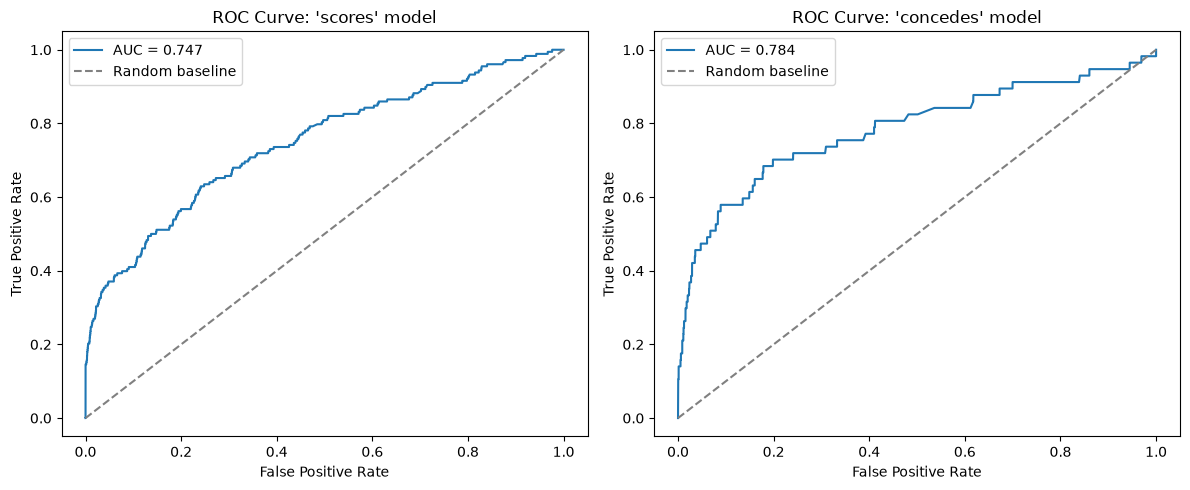

In [29]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label in zip(axes, ['scores', 'concedes']):
    preds = models[label].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test[label], preds)
    auc = roc_auc_score(Y_test[label], preds)
    
    ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], '--', color='grey', label='Random baseline')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"ROC Curve: '{label}' model")
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Validating the models properly using cross-validation and training curves

A single train/test split and one AUC number is only a point estimate, it doesn't show how much performance would vary across different splits, or whether the model is overfitting as boosting iterations increase. Three checks address this directly:

1. **5-fold stratified cross-validation** — gives a mean AUC *and* a standard deviation across 5 different train/test splits, rather than trusting one split. Stratification matters here specifically because positive labels (goals) are rare.
2. **Training vs. validation loss curves** — plots loss at every one of the 100 boosting stages, on both training and held-out data, to check for overfitting (validation loss climbing while training loss keeps falling).
3. **Multi-seed stability check** — refits the model with 10 different random seeds to visualise how consistent training is, beyond a single fixed-seed run.

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_results = {}
for label in ['scores', 'concedes']:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    cv_scores = cross_val_score(cv_model, X_full, Y_full[label], cv=skf, scoring='roc_auc')
    cv_results[label] = cv_scores
    print(f"{label}: AUC = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  (5-fold CV)")
    print(f"  individual folds: {[f'{s:.3f}' for s in cv_scores]}")

scores: AUC = 0.739 ± 0.007  (5-fold CV)
  individual folds: ['0.733', '0.744', '0.728', '0.747', '0.744']
concedes: AUC = 0.751 ± 0.033  (5-fold CV)
  individual folds: ['0.764', '0.782', '0.740', '0.776', '0.692']


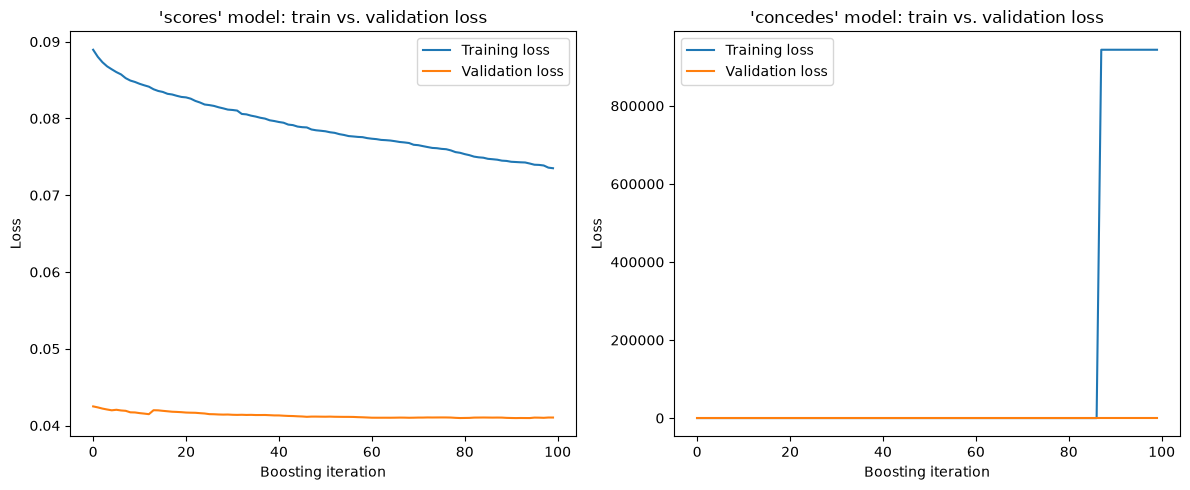

In [31]:
from sklearn.metrics import log_loss

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label in zip(axes, ['scores', 'concedes']):
    diag_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
    diag_model.fit(X_train, Y_train[label])

    train_loss = diag_model.train_score_  # deviance at each boosting stage, on training data

    test_loss = []
    for y_pred_proba in diag_model.staged_predict_proba(X_test):
        test_loss.append(log_loss(Y_test[label], y_pred_proba[:, 1]))

    ax.plot(train_loss, label='Training loss')
    ax.plot(test_loss, label='Validation loss')
    ax.set_xlabel('Boosting iteration')
    ax.set_ylabel('Loss')
    ax.set_title(f"'{label}' model: train vs. validation loss")
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

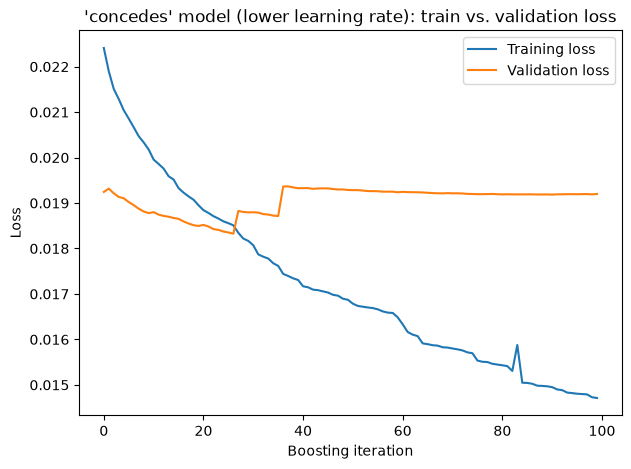

New concedes AUC: 0.823


In [51]:
concedes_model_v2 = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42
)
concedes_model_v2.fit(X_train, Y_train['concedes'])

test_loss_v2 = [log_loss(Y_test['concedes'], p[:, 1]) for p in concedes_model_v2.staged_predict_proba(X_test)]
train_loss_v2 = concedes_model_v2.train_score_

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_loss_v2, label='Training loss')
ax.plot(test_loss_v2, label='Validation loss')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('Loss')
ax.set_title("'concedes' model (lower learning rate): train vs. validation loss")
ax.legend()
plt.savefig('../figures/concedes_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"New concedes AUC: {roc_auc_score(Y_test['concedes'], concedes_model_v2.predict_proba(X_test)[:,1]):.3f}")

Identified instability in the conceding model due to severe class imbalance; resolved by reducing the learning rate.

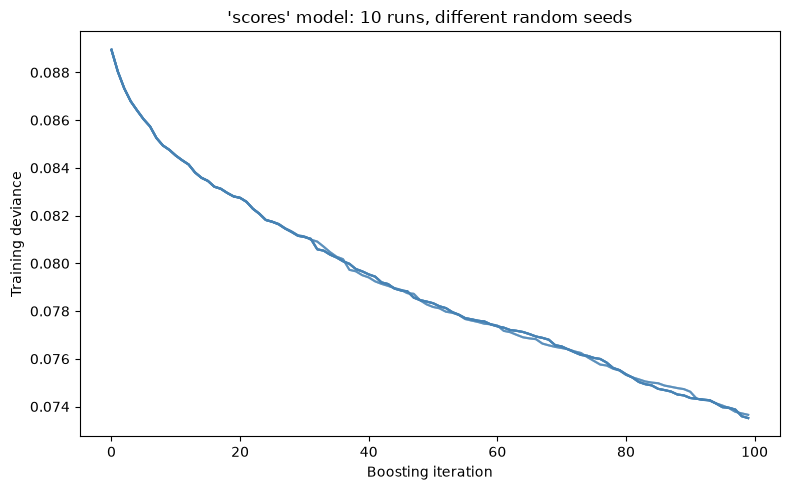

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
for seed in range(10):
    seed_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=seed)
    seed_model.fit(X_train, Y_train['scores'])
    ax.plot(seed_model.train_score_, alpha=0.5, color='steelblue')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('Training deviance')
ax.set_title("'scores' model: 10 runs, different random seeds")
plt.tight_layout()
plt.savefig('../figures/multi_seed_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Compute VAEP values for every real action

With both models trained, compute the actual VAEP value for every action in the dataset using the formula from the proposal (Equation 2.1): the change in P(scores) minus the change in P(concedes), before vs. after each action. This gives every real pass, dribble, shot, etc. an action value — the foundation for comparing chosen passes against counterfactual alternatives in RQ1.

In [33]:
from socceraction.vaep.formula import value

Pscores = models['scores'].predict_proba(X_full)[:, 1]
Pconcedes = models['concedes'].predict_proba(X_full)[:, 1]

action_values = value(
    actions_full.reset_index(drop=True),
    pd.Series(Pscores),
    pd.Series(Pconcedes)
)

print(action_values.describe())
print(f"\nHighest-value actions:")
top_actions = pd.concat([actions_full.reset_index(drop=True), action_values], axis=1)
top_actions.sort_values('vaep_value', ascending=False)[
    ['type_name', 'result_name', 'team_id', 'vaep_value']
].head(10)

       offensive_value  defensive_value     vaep_value
count    109985.000000    109985.000000  109985.000000
mean          0.001517         0.000016       0.001533
std           0.036103         0.029243       0.045698
min          -0.995680        -1.000000      -1.524094
25%          -0.000767        -0.000094      -0.000791
50%           0.000368         0.000000       0.000381
75%           0.002085         0.000197       0.002323
max           1.000000         0.999953       1.064986

Highest-value actions:


,type_name,result_name,team_id,vaep_value
21766,shot,success,770,1.064986
80279,dribble,success,768,1.018086
102024,dribble,success,771,1.010341
91202,shot,success,909,1.009009
2098,pass,success,773,1.005639
23922,shot,success,773,1.005577
59674,shot,success,905,1.005297
24603,dribble,success,773,1.003334
37974,shot,success,782,1.002164
68881,dribble,success,771,1.001152


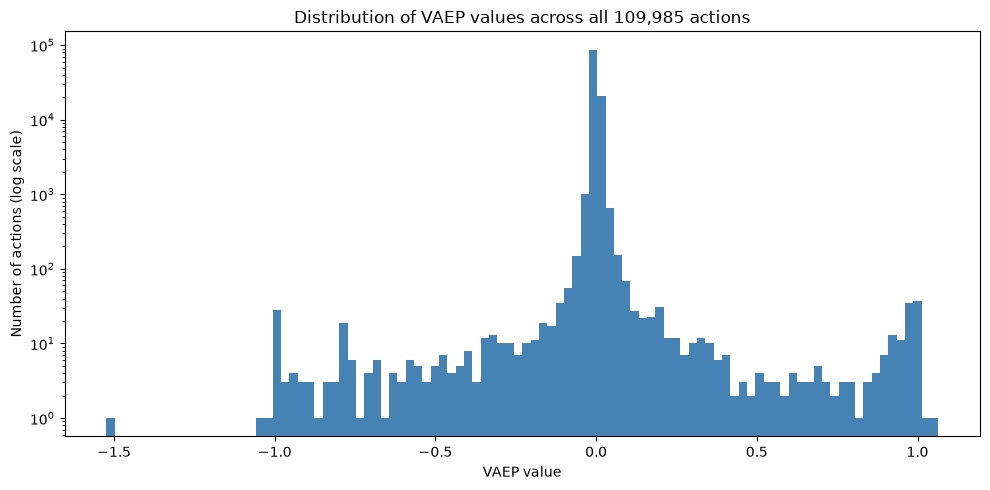

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(action_values['vaep_value'], bins=100, color='steelblue', edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('VAEP value')
ax.set_ylabel('Number of actions (log scale)')
ax.set_title('Distribution of VAEP values across all 109,985 actions')
plt.tight_layout()
plt.savefig('../figures/vaep_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**What this shows:** every one of the 109,985 actions across all 51 matches now has a VAEP value which shows how much that action changed the team's chance of scoring vs. conceding. The distribution centers just above zero (most actions barely move the needle) with a long right tail of highly valuable actions. The top-10 table confirms this makes football sense: the highest-value actions are shots and dribbles into dangerous positions, exactly what should carry the most value. This is the foundation the counterfactual comparison (RQ1) will be built on next.

Identify and exclude goal-assist passes from counterfactual search

A pass that directly assisted a goal has already achieved close to the maximum possible value on the VAEP scale as asking whether a "better" alternative existed is close to meaningless, since nothing outvalues a goal. These passes are excluded from the counterfactual comparison in RQ1 and RQ2, documented as a methodological choice.

In [35]:
goal_assist_ids = set()

for f in match_files:
    mid = f.split('match_')[1].split('.pkl')[0]
    m_events = sb.events(match_id=mid)
    
    if 'pass_goal_assist' in m_events.columns:
        assists = m_events[m_events['pass_goal_assist'] == True]['id'].tolist()
        goal_assist_ids.update(assists)

print(f"{len(goal_assist_ids)} goal-assist passes found across all 51 matches (to be excluded from counterfactual search)")

70 goal-assist passes found across all 51 matches (to be excluded from counterfactual search)


Only the direct goal-assist pass was excluded from counterfactual comparison; earlier build-up actions retained their counterfactual analysis, as VAEP's value already reflects their reduced and less certain contribution relative to the assist itself.

Counterfactual pass construction : single pass test

For one real pass (excluding goal-assists), construct hypothetical versions targeting each candidate teammate from the 360 freeze frame instead of the actual receiver. Recompute features for each hypothetical action, and use the already-trained VAEP models to value them. This validates the counterfactual logic on one example before scaling to the full dataset.

In [36]:
print([c for c in actions_full.columns if 'event' in c.lower() or 'id' in c.lower()])

['game_id', 'original_event_id', 'period_id', 'team_id', 'player_id', 'type_id', 'result_id', 'bodypart_id', 'action_id']


In [37]:
sample_match_events = sb.events(match_id="3930158")
sample_events_oriented = add_orientation_vectors(sample_match_events)

candidates = actions_full[
    (actions_full['type_name'] == 'pass') &
    (actions_full['result_name'] == 'success') &
    (~actions_full['original_event_id'].isin(goal_assist_ids))
].copy()

valid_event_ids = set(sample_events_oriented[sample_events_oriented['orientation_vector'].notna()]['id'])
candidates_with_orientation = candidates[candidates['original_event_id'].isin(valid_event_ids)]

sample_pass = candidates_with_orientation.iloc[100]
sample_match_id = str(sample_pass['game_id'])
sample_event_id = sample_pass['original_event_id']

print(sample_pass[['game_id', 'period_id', 'time_seconds', 'team_id', 'player_id',
                     'start_x', 'start_y', 'end_x', 'end_y']])

game_id          3930158
period_id              1
time_seconds     683.802
team_id              942
player_id        10540.0
start_x         48.60625
start_y          11.1775
end_x           35.30625
end_y            13.3025
Name: 267, dtype: object


Pull the 360 freeze frame for this pass

To build counterfactual alternatives, we need the actual positions of this pass's teammates at the moment it was made. The `original_event_id` links this SPADL action back to its raw StatsBomb event ID, which is what the 360 freeze frame (`frames` table) is indexed by.

In [38]:
sample_frames = sb.frames(match_id=sample_match_id, fmt='dataframe')

sample_teammates = sample_frames[
    (sample_frames['id'] == sample_event_id) &
    (sample_frames['teammate'] == True) &
    (sample_frames['actor'] == False)
]

print(f"{len(sample_teammates)} candidate teammates found for this pass")
sample_teammates[['location']]

5 candidate teammates found for this pass


,location
6847,"[63.46276628732333, 48.88820303906155]"
6851,"[70.29474375834607, 29.256284311383503]"
6854,"[77.29004575897987, 2.5390027898185252]"
6855,"[77.32998761610416, 21.817563871697597]"
6856,"[77.79781220304908, 11.592996516015816]"


Build hypothetical passes to each candidate teammate

For each candidate teammate, construct a hypothetical action identical to the real pass except the end location is swapped to that teammate's position. This is the core counterfactual construction step where everything else about the game state (who has the ball, when, the preceding two actions) stays the same; only "where did the ball go" changes.

In [39]:
# get the real action's row (with all SPADL columns) and its two preceding actions,
# since VAEP features depend on a 3-action window (gamestates)
sample_idx = actions_full.index[actions_full['original_event_id'] == sample_event_id][0]

context_window = actions_full.loc[sample_idx-2:sample_idx].copy()
print("Context window (2 prior actions + the real pass):")
context_window[['type_name', 'result_name', 'start_x', 'start_y', 'end_x', 'end_y']]

Context window (2 prior actions + the real pass):


,type_name,result_name,start_x,start_y,end_x,end_y
265,pass,success,38.01875,3.6975,48.95625,8.8825
266,dribble,success,48.95625,8.8825,48.60625,11.1775
267,pass,success,48.60625,11.1775,35.30625,13.3025


Classify the candidate teammates using Layer 1's vision cone

Reuse the vision-cone logic from `src/vision_cone.py` to classify these 9 candidates as visible or invisible, using the same orientation proxy approach as Layer 1. This produces the two candidate sets needed for RQ1: all teammates (omniscient) vs. only visible teammates (filtered).

In [40]:
from src.vision_cone import angle_to_teammate

matching_event = sample_events_oriented[sample_events_oriented['id'] == sample_event_id].iloc[0]
passer_loc = matching_event['location']
passer_orientation = matching_event['orientation_vector']

print(f"Passer location: {passer_loc}")
print(f"Orientation vector: {passer_orientation}")

sample_teammates = sample_teammates.copy()
sample_teammates['angle_to_orientation'] = sample_teammates['location'].apply(
    lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
)
sample_teammates['visible'] = sample_teammates['angle_to_orientation'] <= 60

print(f"\n{sample_teammates['visible'].sum()} of {len(sample_teammates)} candidates are visible (within 120° cone)")
sample_teammates[['location', 'angle_to_orientation', 'visible']]

Passer location: [64.5, 13.2]
Orientation vector: (0.1465486610894644, 0.9892034623538705)

3 of 5 candidates are visible (within 120° cone)


,location,angle_to_orientation,visible
6847,"[63.46276628732333, 48.88820303906155]",10.091732,True
6851,"[70.29474375834607, 29.256284311383503]",11.417641,True
6854,"[77.29004575897987, 2.5390027898185252]",121.385543,False
6855,"[77.32998761610416, 21.817563871697597]",47.684816,True
6856,"[77.79781220304908, 11.592996516015816]",88.463652,False


Build hypothetical actions for each candidate teammate

For each of the 5 candidates, construct a hypothetical version of the real pass with the end location swapped to that teammate's position. The two preceding actions and all other context stay identical to the real pass, only the destination changes. This produces one hypothetical action per candidate, ready to be valued the same way real actions were.

In [41]:
sample_idx = actions_full.index[actions_full['original_event_id'] == sample_event_id][0]
context_window = actions_full.loc[sample_idx-2:sample_idx].copy()

hypothetical_rows = []

for teammate_idx, teammate_row in sample_teammates.iterrows():
    hyp_window = context_window.copy()
    # only the last action (the real pass) gets its end location swapped
    hyp_window.iloc[-1, hyp_window.columns.get_loc('end_x')] = teammate_row['location'][0]
    hyp_window.iloc[-1, hyp_window.columns.get_loc('end_y')] = teammate_row['location'][1]
    hyp_window['candidate_teammate_idx'] = teammate_idx
    hyp_window['visible'] = teammate_row['visible']
    hypothetical_rows.append(hyp_window)

print(f"{len(hypothetical_rows)} hypothetical action windows built")
print("\nExample - real pass end location vs hypothetical:")
print(f"  Real:        end_x={context_window.iloc[-1]['end_x']:.2f}, end_y={context_window.iloc[-1]['end_y']:.2f}")
print(f"  Hypothetical: end_x={hypothetical_rows[0].iloc[-1]['end_x']:.2f}, end_y={hypothetical_rows[0].iloc[-1]['end_y']:.2f}")

5 hypothetical action windows built

Example - real pass end location vs hypothetical:
  Real:        end_x=35.31, end_y=13.30
  Hypothetical: end_x=63.46, end_y=48.89


Recompute VAEP features for each hypothetical action, and value them

For each hypothetical action window, recompute the same features used for real actions (action type, result, start/end location, team, time delta), since changing the end location changes those feature values (e.g. distance and angle to goal). Feed each hypothetical window through the already-trained scoring/conceding models to get a hypothetical VAEP value, using the same pre-action state as the real pass.

In [42]:
hypothetical_values = []

for hyp_window in hypothetical_rows:
    hyp_gamestates = fs.gamestates(hyp_window, nb_prev_actions=3)
    hyp_X = pd.concat([f(hyp_gamestates) for f in feature_functions], axis=1)

    hyp_Pscores = models['scores'].predict_proba(hyp_X)[:, 1]
    hyp_Pconcedes = models['concedes'].predict_proba(hyp_X)[:, 1]

    hyp_window_reset = hyp_window.reset_index(drop=True)

    # pass the FULL window so _prev() shifting works correctly
    hyp_action_value_full = value(
        hyp_window_reset,
        pd.Series(hyp_Pscores),
        pd.Series(hyp_Pconcedes)
    )

    # only the last row (the actual hypothetical pass) is what we care about
    hyp_action_value = hyp_action_value_full.iloc[-1]

    hypothetical_values.append({
        'candidate_teammate_idx': hyp_window['candidate_teammate_idx'].iloc[0],
        'visible': hyp_window['visible'].iloc[0],
        'end_x': hyp_window.iloc[-1]['end_x'],
        'end_y': hyp_window.iloc[-1]['end_y'],
        'hypothetical_vaep_value': hyp_action_value['vaep_value']
    })

hyp_df = pd.DataFrame(hypothetical_values)
print("Hypothetical alternatives:")
hyp_df.sort_values('hypothetical_vaep_value', ascending=False)

Hypothetical alternatives:


c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\vaep\features.py:94: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.shift(i, fill_value=float("nan")).fillna(x.iloc[0])  # noqa: B023
c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\vaep\features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions.groupby(["game_id", "period_id"], sort=False, as_index=False).apply(
c:\Users\raees

,candidate_teammate_idx,visible,end_x,end_y,hypothetical_vaep_value
1,6851,True,70.294744,29.256284,0.001911
3,6855,True,77.329988,21.817564,0.001390
0,6847,True,63.462766,48.888203,0.000550
4,6856,False,77.797812,11.592997,0.000501
2,6854,False,77.290046,2.539003,0.000034


In [43]:
real_action_value = value(
    context_window.reset_index(drop=True),
    pd.Series(models['scores'].predict_proba(
        pd.concat([f(fs.gamestates(context_window, nb_prev_actions=3)) for f in feature_functions], axis=1)
    )[:, 1]),
    pd.Series(models['concedes'].predict_proba(
        pd.concat([f(fs.gamestates(context_window, nb_prev_actions=3)) for f in feature_functions], axis=1)
    )[:, 1])
).iloc[-1]['vaep_value']

print(f"Real pass VAEP value: {real_action_value:.6f}")
print(f"Best omniscient alternative: {hyp_df['hypothetical_vaep_value'].max():.6f}")
print(f"Best visible-only alternative: {hyp_df[hyp_df['visible']]['hypothetical_vaep_value'].max():.6f}")

Real pass VAEP value: 0.000442
Best omniscient alternative: 0.001911
Best visible-only alternative: 0.001911


c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\vaep\features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions.groupby(["game_id", "period_id"], sort=False, as_index=False).apply(
c:\Users\raees\Documents\Honours\My Research\Code\venv\Lib\site-packages\socceraction\vaep\features.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prev_actions = actions

Scale counterfactual valuation to the full competition (+ capture invisible-teammate data for Layer 3)

Package the single-pass logic into a function that processes one match at a time, looping over all its non-goal-assist passes with valid orientation and 360 data. For each qualifying pass, compute: the real action's VAEP value, the best hypothetical value among all candidates (omniscient), and the best hypothetical value among only visible candidates (Layer 1 filtered).

While iterating through each pass's 360 frame here, also capture the ground-truth positions of any **invisible** teammates. This is the evaluation target Layer 3's LSTM will later be checked against (RQ3's MAPE metric) , capturing it now avoids a second expensive full-competition data pull later. Note: this saves ground-truth *positions*, not full trajectory sequences (the LSTM's actual training input), trajectory extraction is a separate step to build when Layer 3 begins properly.

Results are saved per match (both the counterfactual comparison and the LSTM evaluation data), so this can resume if interrupted : same pattern as scaling Layer 1.

In [ ]:
import os
os.makedirs('../data/counterfactuals', exist_ok=True)
os.makedirs('../data/lstm_eval', exist_ok=True)

def process_match_counterfactuals(mid):
    m_events = sb.events(match_id=mid)
    m_events_oriented = add_orientation_vectors(m_events)
    m_frames = sb.frames(match_id=mid, fmt='dataframe')

    m_actions = actions_full[actions_full['game_id'] == int(mid)].sort_values('action_id').reset_index(drop=True)

    valid_event_ids = set(m_events_oriented[m_events_oriented['orientation_vector'].notna()]['id'])

    qualifying = m_actions[
        (m_actions['type_name'] == 'pass') &
        (m_actions['result_name'] == 'success') &
        (~m_actions['original_event_id'].isin(goal_assist_ids)) &
        (m_actions['original_event_id'].isin(valid_event_ids))
    ]

    results = []
    lstm_eval_rows = []

    for idx in qualifying.index:
        if idx < 2:
            continue  # not enough prior actions for a 3-action window

        event_id = m_actions.loc[idx, 'original_event_id']
        teammates = m_frames[
            (m_frames['id'] == event_id) &
            (m_frames['teammate'] == True) &
            (m_frames['actor'] == False)
        ]
        if teammates.empty:
            continue

        matching_event = m_events_oriented[m_events_oriented['id'] == event_id].iloc[0]
        passer_loc = matching_event['location']
        passer_orientation = matching_event['orientation_vector']

        teammates = teammates.copy()
        teammates['angle_to_orientation'] = teammates['location'].apply(
            lambda loc: angle_to_teammate(passer_loc, passer_orientation, loc)
        )
        teammates = teammates.dropna(subset=['angle_to_orientation'])
        if teammates.empty:
            continue
        teammates['visible'] = teammates['angle_to_orientation'] <= 60

        # capture invisible teammates' ground-truth locations for later LSTM evaluation (RQ3)
        invisible_teammates = teammates[~teammates['visible']]
        for _, inv in invisible_teammates.iterrows():
            lstm_eval_rows.append({
                'match_id': mid,
                'original_event_id': event_id,
                'teammate_location': inv['location'],
                'passer_location': passer_loc,
                'time_seconds': matching_event.get('timestamp', None)
            })

        context_window = m_actions.loc[idx-2:idx].copy()

        hyp_windows = []
        for _, tm in teammates.iterrows():
            hw = context_window.copy()
            hw.iloc[-1, hw.columns.get_loc('end_x')] = tm['location'][0]
            hw.iloc[-1, hw.columns.get_loc('end_y')] = tm['location'][1]
            hw['visible'] = tm['visible']
            hyp_windows.append(hw)

        hyp_values = []
        for hw in hyp_windows:
            hw_reset = hw.reset_index(drop=True)
            gs = fs.gamestates(hw_reset, nb_prev_actions=3)
            X_hyp = pd.concat([f(gs) for f in feature_functions], axis=1)
            ps = models['scores'].predict_proba(X_hyp)[:, 1]
            pc = models['concedes'].predict_proba(X_hyp)[:, 1]
            v = value(hw_reset, pd.Series(ps), pd.Series(pc)).iloc[-1]['vaep_value']
            hyp_values.append({'visible': hw['visible'].iloc[0], 'value': v})

        hyp_df_row = pd.DataFrame(hyp_values)

        gs_real = fs.gamestates(context_window.reset_index(drop=True), nb_prev_actions=3)
        X_real = pd.concat([f(gs_real) for f in feature_functions], axis=1)
        ps_real = models['scores'].predict_proba(X_real)[:, 1]
        pc_real = models['concedes'].predict_proba(X_real)[:, 1]
        real_value = value(context_window.reset_index(drop=True), pd.Series(ps_real), pd.Series(pc_real)).iloc[-1]['vaep_value']

        visible_only = hyp_df_row[hyp_df_row['visible']]

        results.append({
            'match_id': mid,
            'original_event_id': event_id,
            'real_value': real_value,
            'best_omniscient_value': hyp_df_row['value'].max(),
            'best_visible_value': visible_only['value'].max() if not visible_only.empty else None,
            'n_candidates': len(hyp_df_row),
            'n_visible': int(hyp_df_row['visible'].sum())
        })

    return pd.DataFrame(results), pd.DataFrame(lstm_eval_rows)


all_matches_list = matches['match_id'].tolist()
failed_cf_matches = []

for i, mid in enumerate(all_matches_list):
    save_path = f'../data/counterfactuals/cf_match_{mid}.pkl'
    lstm_save_path = f'../data/lstm_eval/lstm_eval_match_{mid}.pkl'

    if os.path.exists(save_path):
        continue
    try:
        result_df, lstm_eval_df = process_match_counterfactuals(str(mid))
        result_df.to_pickle(save_path)
        lstm_eval_df.to_pickle(lstm_save_path)
        print(f"[{i+1}/{len(all_matches_list)}] match {mid}: {len(result_df)} passes, {len(lstm_eval_df)} invisible-teammate rows saved")
    except Exception as e:
        print(f"[{i+1}/{len(all_matches_list)}] match {mid} FAILED: {e}")
        failed_cf_matches.append(mid)

print(f"\nDone. {len(failed_cf_matches)} matches failed: {failed_cf_matches}")

In [44]:
import glob

cf_files = glob.glob('../data/counterfactuals/cf_match_*.pkl')
lstm_files = glob.glob('../data/lstm_eval/lstm_eval_match_*.pkl')

print(f"Counterfactual result files: {len(cf_files)} (should be 51)")
print(f"LSTM eval files: {len(lstm_files)} (should be 51)")

Counterfactual result files: 51 (should be 51)
LSTM eval files: 51 (should be 51)


In [45]:
test_load = pd.read_pickle(cf_files[0])
print(test_load.shape)
test_load.head()

(680, 7)


,match_id,original_event_id,real_value,best_omniscient_value,best_visible_value,n_candidates,n_visible
0,3930158,06b36608-b428-452b-a809-ca0a2a0f259b,0.016696,0.001435,NaN,9,0
1,3930158,79aa9f3e-52cc-46f2-a002-8f2ab8fbc171,0.000073,0.002659,0.000073,6,2
2,3930158,865f49e1-6341-421e-89e5-d6e084c1d1ff,-0.002155,-0.000639,-0.001548,7,2
3,3930158,910595a9-e1ff-4be1-98d5-965be6b0905d,0.000389,0.000976,0.000102,7,4
4,3930158,7a31d6b0-c412-4f2f-af93-eea93bc34e69,-0.000513,0.000361,0.000361,6,1


In [46]:
cf_full = pd.concat([pd.read_pickle(f) for f in cf_files], ignore_index=True)

print(f"Total passes with counterfactual comparison: {len(cf_full)}")

cf_valid = cf_full.dropna(subset=['best_visible_value']).copy()
print(f"Passes with at least one visible alternative: {len(cf_valid)}")

cf_valid['value_reduction'] = cf_valid['best_omniscient_value'] - cf_valid['best_visible_value']
cf_valid['identity_changes'] = cf_valid['best_omniscient_value'] != cf_valid['best_visible_value']

print(f"\nMean best omniscient value:    {cf_valid['best_omniscient_value'].mean():.5f}")
print(f"Mean best visible-only value:  {cf_valid['best_visible_value'].mean():.5f}")
print(f"Mean reduction after filtering: {cf_valid['value_reduction'].mean():.5f}")
print(f"\nProportion of passes where filtering changes the optimal alternative: {cf_valid['identity_changes'].mean():.1%}")

from scipy import stats
d = (cf_valid['best_omniscient_value'].mean() - cf_valid['best_visible_value'].mean()) / cf_valid['best_omniscient_value'].std()
print(f"Cohen's d effect size: {d:.3f}")

Total passes with counterfactual comparison: 31537
Passes with at least one visible alternative: 26591

Mean best omniscient value:    0.02562
Mean best visible-only value:  0.01579
Mean reduction after filtering: 0.00983

Proportion of passes where filtering changes the optimal alternative: 59.1%
Cohen's d effect size: 0.089


In [47]:
diffs = cf_valid['best_omniscient_value'] - cf_valid['best_visible_value']
d_paired = diffs.mean() / diffs.std()
print(f"Paired Cohen's d: {d_paired:.3f}")

from scipy.stats import wilcoxon
stat, p = wilcoxon(cf_valid['best_omniscient_value'], cf_valid['best_visible_value'])
print(f"Wilcoxon signed-rank test: statistic={stat:.1f}, p-value={p:.2e}")

Paired Cohen's d: 0.166
Wilcoxon signed-rank test: statistic=0.0, p-value=0.00e+00


Comparing the real chosen pass to its alternatives

So far the RQ1 comparison has looked at omniscient-optimal vs. visible-optimal. It's also worth directly checking how the pass the player *actually made* compares to both — this is a preview of RQ2's core question (was the chosen pass already the best visible option, or was something better available?).

In [48]:
print(f"Mean real pass value:          {cf_valid['real_value'].mean():.5f}")
print(f"Mean best omniscient value:    {cf_valid['best_omniscient_value'].mean():.5f}")
print(f"Mean best visible-only value:  {cf_valid['best_visible_value'].mean():.5f}")

# how often was the chosen pass already the best visible option?
cf_valid['chose_best_visible'] = cf_valid['real_value'] >= cf_valid['best_visible_value']
print(f"\nProportion of passes where the chosen pass was already optimal among visible options: {cf_valid['chose_best_visible'].mean():.1%}")

Mean real pass value:          0.00000
Mean best omniscient value:    0.02562
Mean best visible-only value:  0.01579

Proportion of passes where the chosen pass was already optimal among visible options: 27.2%


72.8% of the time, the pass a player actually chose was not the best available option among their visible teammates. That's a much bigger number than the 59.1% "identity changes" finding from RQ1, and it's your first real hint that RQ2 (actual decision-making bias) might be a substantial effect — not just a perception one.

However, this "best visible" figure is currently unconstrained — it doesn't yet account for offside or pass difficulty (xP), which you've already correctly identified need to gate what counts as a legitimate alternative. So 72.8% is likely an overestimate of true bias right now; some of those "better" visible options were probably offside or unrealistically difficult to execute. Worth noting as a preliminary number, not a final RQ2 result — but a strong signal that the bias analysis is going to find something real once the proper filters are in place.

In [52]:
print(cf_valid['real_value'].describe())
print(f"\nMean to more decimal places: {cf_valid['real_value'].mean():.8f}")

count    26591.000000
mean         0.000004
std          0.027097
min         -1.014757
25%         -0.001532
50%         -0.000219
75%          0.001065
max          1.012287
Name: real_value, dtype: float64

Mean to more decimal places: 0.00000371


In [49]:
os.makedirs('../data/results', exist_ok=True)

cf_valid.to_pickle('../data/results/rq1_counterfactual_comparison.pkl')

rq1_summary = {
    'total_passes_compared': len(cf_full),
    'passes_with_visible_alternative': len(cf_valid),
    'mean_omniscient_value': cf_valid['best_omniscient_value'].mean(),
    'mean_visible_value': cf_valid['best_visible_value'].mean(),
    'mean_reduction': cf_valid['value_reduction'].mean(),
    'proportion_identity_changed': cf_valid['identity_changes'].mean(),
    'paired_cohens_d': d_paired,
    'wilcoxon_statistic': stat,
    'wilcoxon_pvalue': p
}

pd.to_pickle(rq1_summary, '../data/results/rq1_summary_stats.pkl')

print("Saved:")
print("  ../data/results/rq1_counterfactual_comparison.pkl")
print("  ../data/results/rq1_summary_stats.pkl")
print("\nRQ1 summary:")
for k, v in rq1_summary.items():
    print(f"  {k}: {v}")

Saved:
  ../data/results/rq1_counterfactual_comparison.pkl
  ../data/results/rq1_summary_stats.pkl

RQ1 summary:
  total_passes_compared: 31537
  passes_with_visible_alternative: 26591
  mean_omniscient_value: 0.02561555099751477
  mean_visible_value: 0.015785935435782415
  mean_reduction: 0.009829615561732357
  proportion_identity_changed: 0.59087661238765
  paired_cohens_d: 0.16648370326337802
  wilcoxon_statistic: 0.0
  wilcoxon_pvalue: 0.0


## Supplementary notes: methodology detail for report later 

**VAEP formula (proposal Eq. 2.1):**

$$V(a_i) = \left[P_{scores}(S_i) - P_{scores}(S_{i-1})\right] - \left[P_{concedes}(S_i) - P_{concedes}(S_{i-1})\right]$$

The value of an action is the change in the team's probability of scoring soon, minus the change in their probability of conceding soon, comparing the game state just before and just after the action.

**What the RQ1 statistics mean:**
- **Mean reduction (0.0098):** the average drop in the "best possible pass" value once the comparison is restricted to only visible teammates. VAEP values cluster tightly near zero for most actions, so this is a small but real average shift.
- **Paired Cohen's d (0.166):** a standardised measure of that gap's size relative to normal spread in the data. By convention, d < 0.2 is a small effect, 0.5 medium, 0.8 large — this sits just under the "small" threshold, but is consistent across a very large sample (26,591 paired comparisons).
- **Wilcoxon signed-rank test (p ≈ 0):** confirms the *direction* of the paired differences is consistent. Because visible teammates are always a subset of all teammates, the visible-only optimum can mathematically never exceed the omniscient optimum — so this near-zero p-value confirms the comparison is structured correctly, not that a surprising effect was discovered. The magnitude figures above (mean reduction, d, and the 59.1% identity-change rate) are where the actual finding lives.

**Pass/action count funnel, fully differentiated:**

| Number | What it is | Why smaller than the last |
|---|---|---|
| 109,985 | Every action of every type (passes, dribbles, shots, etc.), all 51 matches | Base unit for VAEP training — values all actions, not just passes |
| 46,593 | Passes with a valid orientation proxy computed | Restricted to passes with a prior touch to compute the movement vector from (~88% of all passes) |
| 31,537 | Passes with a full counterfactual comparison attempted | Further restricted: successful, not a goal-assist, has 360 data, has enough prior actions for VAEP's context window |
| 26,591 | Of those, passes with at least one *visible* candidate teammate | ~16% of qualifying passes had zero visible candidates at all — a separate, notable finding on its own |


## RQ1 result summary

**Research question:** To what degree does applying the 120° perception-inspired vision-cone filter change the distribution of "optimal" counterfactual passes compared to a traditional omniscient model?

**Result:** Across 26,591 passes with at least one visible alternative, restricting counterfactual comparison to only teammates within the passer's 120° vision cone changed the identified optimal alternative in **59.1%** of cases, compared to an omniscient model considering all teammates. The average value of the best visible-only alternative was 0.0098 lower than the best omniscient alternative (paired Cohen's d = 0.166 — a small-to-moderate, but consistent, effect).

**Interpretation:** because visible teammates are always a subset of all teammates, the visible-only optimum can never exceed the omniscient optimum, the direction of this effect is guaranteed by construction, so statistical significance testing (Wilcoxon signed-rank, p≈0) confirms the comparison is measuring correctly rather than revealing an unexpected discovery. The meaningful finding is the *magnitude*: existing omniscient models frequently point to a different "ideal" pass than what a player could plausibly have seen (59% of the time), even though the value gap between the two options tends to be modest in any single instance. This supports the core motivation of this project — that a meaningful proportion of the "missed value" flagged by traditional models may be an artifact of the unrealistic omniscient assumption, consistent with hypothesis H1.

**Not yet incorporated (planned refinements):**
- xP-based feasibility weighting (defender proximity), per proposal Section 4.6
- Offside filtering of candidate counterfactual receivers
- Stratification by player position / pitch zone

**Data used for this result:** all 51 Euro 2024 matches, 46,593 total passes, 31,537 with a computed counterfactual comparison, 26,591 with at least one visible alternative.